In [62]:
from pathlib import Path
import sys
import os

# ============================================================
# SENTINEL AI PROJECT PATHS
# ============================================================

AI_ROOT = Path(r"C:\Users\MALAY\sentinel\ai")

APP_ROOT = AI_ROOT / "app"

DATASET_PATH = AI_ROOT / "datasets" / "phiusiil.csv"

MODEL_ROOT = AI_ROOT / "models"

PHISHING_MODEL_DIR = MODEL_ROOT / "phishing"

# Create model directory if it doesn't exist
PHISHING_MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Add app directory to Python path
if str(APP_ROOT) not in sys.path:
    sys.path.insert(0, str(APP_ROOT))

print("AI ROOT:")
print(AI_ROOT)

print("\nAPP ROOT:")
print(APP_ROOT)

print("\nDATASET:")
print(DATASET_PATH)

print("\nMODEL DIRECTORY:")
print(PHISHING_MODEL_DIR)

print("\nDataset exists:", DATASET_PATH.exists())
print("Loader directory exists:", (APP_ROOT / "src").exists())

AI ROOT:
C:\Users\MALAY\sentinel\ai

APP ROOT:
C:\Users\MALAY\sentinel\ai\app

DATASET:
C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv

MODEL DIRECTORY:
C:\Users\MALAY\sentinel\ai\models\phishing

Dataset exists: True
Loader directory exists: True


In [63]:
from src.data_loader import load_phishing_dataset

print("data_loader imported successfully!")

data_loader imported successfully!


In [64]:
df = load_phishing_dataset()

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Loading dataset from:
C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv
Dataset loaded successfully.
Shape: (235795, 56)
Dataset loaded successfully!
Shape: (235795, 56)


In [65]:
df.head()

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [66]:
df.sample(10)

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
171817,mw201610.txt,http://www.zone-812.ml,22,www.zone-812.ml,15,0,ml,65.840220,1.000000,0.000131,...,0,0,0,0,0,0,0,0,0,0
19613,m2w00505.txt,https://www.achauthorization.pages.dev,37,www.achauthorization.pages.dev,30,0,dev,44.492308,0.772727,0.000961,...,0,0,0,0,0,0,0,0,0,0
98328,116329.txt,https://www.as.miami.edu,23,www.as.miami.edu,16,0,edu,100.000000,0.750000,0.011501,...,0,0,1,14,11,20,13,3,94,1
157206,8048753.txt,https://abbbbbbbbbbbbbbbbbbbbbbb-be3fd.web.app/,47,abbbbbbbbbbbbbbbbbbbbbbb-be3fd.web.app,38,0,app,25.847006,0.764706,0.001502,...,0,0,0,0,0,0,0,0,3,0
15560,742884.txt,https://www.suzuki.com.au,24,www.suzuki.com.au,17,0,au,100.000000,0.700000,0.010086,...,0,0,1,18,2,10,6,0,6,1
6811,426293.txt,https://www.timescontent.com,27,www.timescontent.com,20,0,com,100.000000,1.000000,0.522907,...,1,0,1,22,2,29,89,2,3,1
188890,148730.txt,https://www.kewlabstech.com,26,www.kewlabstech.com,19,0,com,100.000000,1.000000,0.522907,...,1,0,1,27,40,76,120,6,129,1
134098,8123383.txt,https://yellow-hill-cabc.lstiloaekyhe2210.work...,54,yellow-hill-cabc.lstiloaekyhe2210.workers.dev,45,0,dev,25.208803,0.414634,0.000961,...,0,0,0,0,2,0,2,0,2,0
115749,243264.txt,https://www.ahhqi.org,20,www.ahhqi.org,13,0,org,100.000000,1.000000,0.079963,...,0,0,1,18,3,3,86,4,9,1
53925,mw38635.txt,http://www.contact.purpledaily.com,33,www.contact.purpledaily.com,27,0,com,61.310649,0.631579,0.522907,...,0,0,0,0,0,0,0,0,0,0


In [67]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
for i, column in enumerate(df.columns):
    print(i, "->", column)

Number of rows: 235795
Number of columns: 56

Columns:
0 -> FILENAME
1 -> URL
2 -> URLLength
3 -> Domain
4 -> DomainLength
5 -> IsDomainIP
6 -> TLD
7 -> URLSimilarityIndex
8 -> CharContinuationRate
9 -> TLDLegitimateProb
10 -> URLCharProb
11 -> TLDLength
12 -> NoOfSubDomain
13 -> HasObfuscation
14 -> NoOfObfuscatedChar
15 -> ObfuscationRatio
16 -> NoOfLettersInURL
17 -> LetterRatioInURL
18 -> NoOfDegitsInURL
19 -> DegitRatioInURL
20 -> NoOfEqualsInURL
21 -> NoOfQMarkInURL
22 -> NoOfAmpersandInURL
23 -> NoOfOtherSpecialCharsInURL
24 -> SpacialCharRatioInURL
25 -> IsHTTPS
26 -> LineOfCode
27 -> LargestLineLength
28 -> HasTitle
29 -> Title
30 -> DomainTitleMatchScore
31 -> URLTitleMatchScore
32 -> HasFavicon
33 -> Robots
34 -> IsResponsive
35 -> NoOfURLRedirect
36 -> NoOfSelfRedirect
37 -> HasDescription
38 -> NoOfPopup
39 -> NoOfiFrame
40 -> HasExternalFormSubmit
41 -> HasSocialNet
42 -> HasSubmitButton
43 -> HasHiddenFields
44 -> HasPasswordField
45 -> Bank
46 -> Pay
47 -> Crypto
48 -> 

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 56 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   FILENAME                    235795 non-null  str    
 1   URL                         235795 non-null  str    
 2   URLLength                   235795 non-null  int64  
 3   Domain                      235795 non-null  str    
 4   DomainLength                235795 non-null  int64  
 5   IsDomainIP                  235795 non-null  int64  
 6   TLD                         235795 non-null  str    
 7   URLSimilarityIndex          235795 non-null  float64
 8   CharContinuationRate        235795 non-null  float64
 9   TLDLegitimateProb           235795 non-null  float64
 10  URLCharProb                 235795 non-null  float64
 11  TLDLength                   235795 non-null  int64  
 12  NoOfSubDomain               235795 non-null  int64  
 13  HasObfuscation           

In [69]:
print(df["label"].value_counts())

label
1    134850
0    100945
Name: count, dtype: int64


In [123]:
import sys
import os

sys.path.insert(
    0,
    r"C:\Users\MALAY\sentinel\ai\app"
)

from services.url_feature_extractor import extract_url_features

print("URL feature extractor imported successfully")

URL feature extractor imported successfully


In [124]:
print("Dataset columns:")
for i, column in enumerate(df.columns):
    print(i, column)

Dataset columns:
0 FILENAME
1 URL
2 URLLength
3 Domain
4 DomainLength
5 IsDomainIP
6 TLD
7 URLSimilarityIndex
8 CharContinuationRate
9 TLDLegitimateProb
10 URLCharProb
11 TLDLength
12 NoOfSubDomain
13 HasObfuscation
14 NoOfObfuscatedChar
15 ObfuscationRatio
16 NoOfLettersInURL
17 LetterRatioInURL
18 NoOfDegitsInURL
19 DegitRatioInURL
20 NoOfEqualsInURL
21 NoOfQMarkInURL
22 NoOfAmpersandInURL
23 NoOfOtherSpecialCharsInURL
24 SpacialCharRatioInURL
25 IsHTTPS
26 LineOfCode
27 LargestLineLength
28 HasTitle
29 Title
30 DomainTitleMatchScore
31 URLTitleMatchScore
32 HasFavicon
33 Robots
34 IsResponsive
35 NoOfURLRedirect
36 NoOfSelfRedirect
37 HasDescription
38 NoOfPopup
39 NoOfiFrame
40 HasExternalFormSubmit
41 HasSocialNet
42 HasSubmitButton
43 HasHiddenFields
44 HasPasswordField
45 Bank
46 Pay
47 Crypto
48 HasCopyrightInfo
49 NoOfImage
50 NoOfCSS
51 NoOfJS
52 NoOfSelfRef
53 NoOfEmptyRef
54 NoOfExternalRef
55 label


In [125]:
test_url = "https://www.google.com"

test_features = extract_url_features(test_url)

print("Number of extracted features:")
print(len(test_features))

print("\nFeatures:")
for key, value in test_features.items():
    print(f"{key:35} : {value}")

Number of extracted features:
22

Features:
URLLength                           : 22
DomainLength                        : 14
IsDomainIP                          : 0
NoOfSubDomain                       : 1
NoOfLettersInURL                    : 17
NoOfDigitsInURL                     : 0
NoOfEqualsInURL                     : 0
NoOfQMarkInURL                      : 0
NoOfAmpersandInURL                  : 0
NoOfOtherSpecialCharsInURL          : 1
NoOfLettersInDomain                 : 12
NoOfDigitsInDomain                  : 0
PathLength                          : 0
IsHTTPS                             : 1
HasPort                             : 0
IsShortenedURL                      : 0
SuspiciousWordCount                 : 0
HasAtSymbol                         : 0
HyphenCount                         : 0
DotCount                            : 2
QueryLength                         : 0
FragmentLength                      : 0


In [70]:
print(df["label"].value_counts(normalize=True) * 100)

label
1    57.189508
0    42.810492
Name: proportion, dtype: float64


C:\Users\MALAY\AppData\Local\Temp\ipykernel_16416\3513184528.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


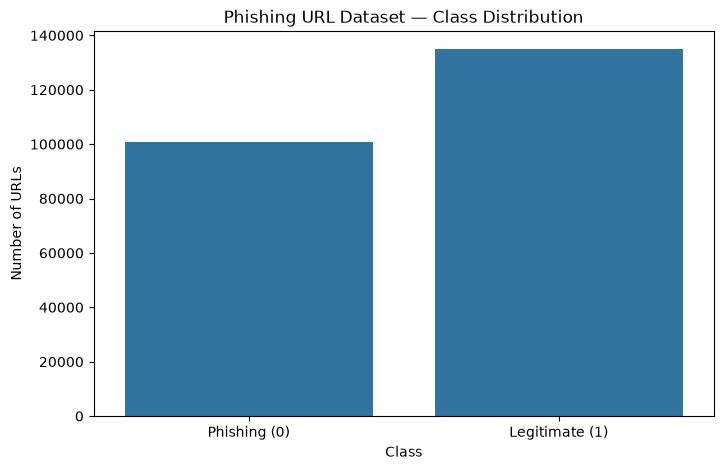

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="label"
)

plt.title("Phishing URL Dataset — Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of URLs")

ax.set_xticklabels([
    "Phishing (0)",
    "Legitimate (1)"
])

plt.show()

In [72]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(
    ascending=False
)

missing

Series([], dtype: int64)

In [73]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage[missing_percentage > 0]

Series([], dtype: float64)

In [74]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [75]:
print(
    "Duplicate percentage:",
    round((duplicate_count / len(df)) * 100, 2),
    "%"
)

Duplicate percentage: 0.0 %


In [76]:
numeric_columns = df.select_dtypes(
    include=["number"]
).columns

print("Numeric columns:")
print(list(numeric_columns))

print("\nNumber of numeric columns:")
print(len(numeric_columns))

Numeric columns:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']

Number of numeric columns:
51


In [77]:
categorical_columns = df.select_dtypes(
    exclude=["number"]
).columns

print("Non-numeric columns:")
print(list(categorical_columns))

Non-numeric columns:
['FILENAME', 'URL', 'Domain', 'TLD', 'Title']


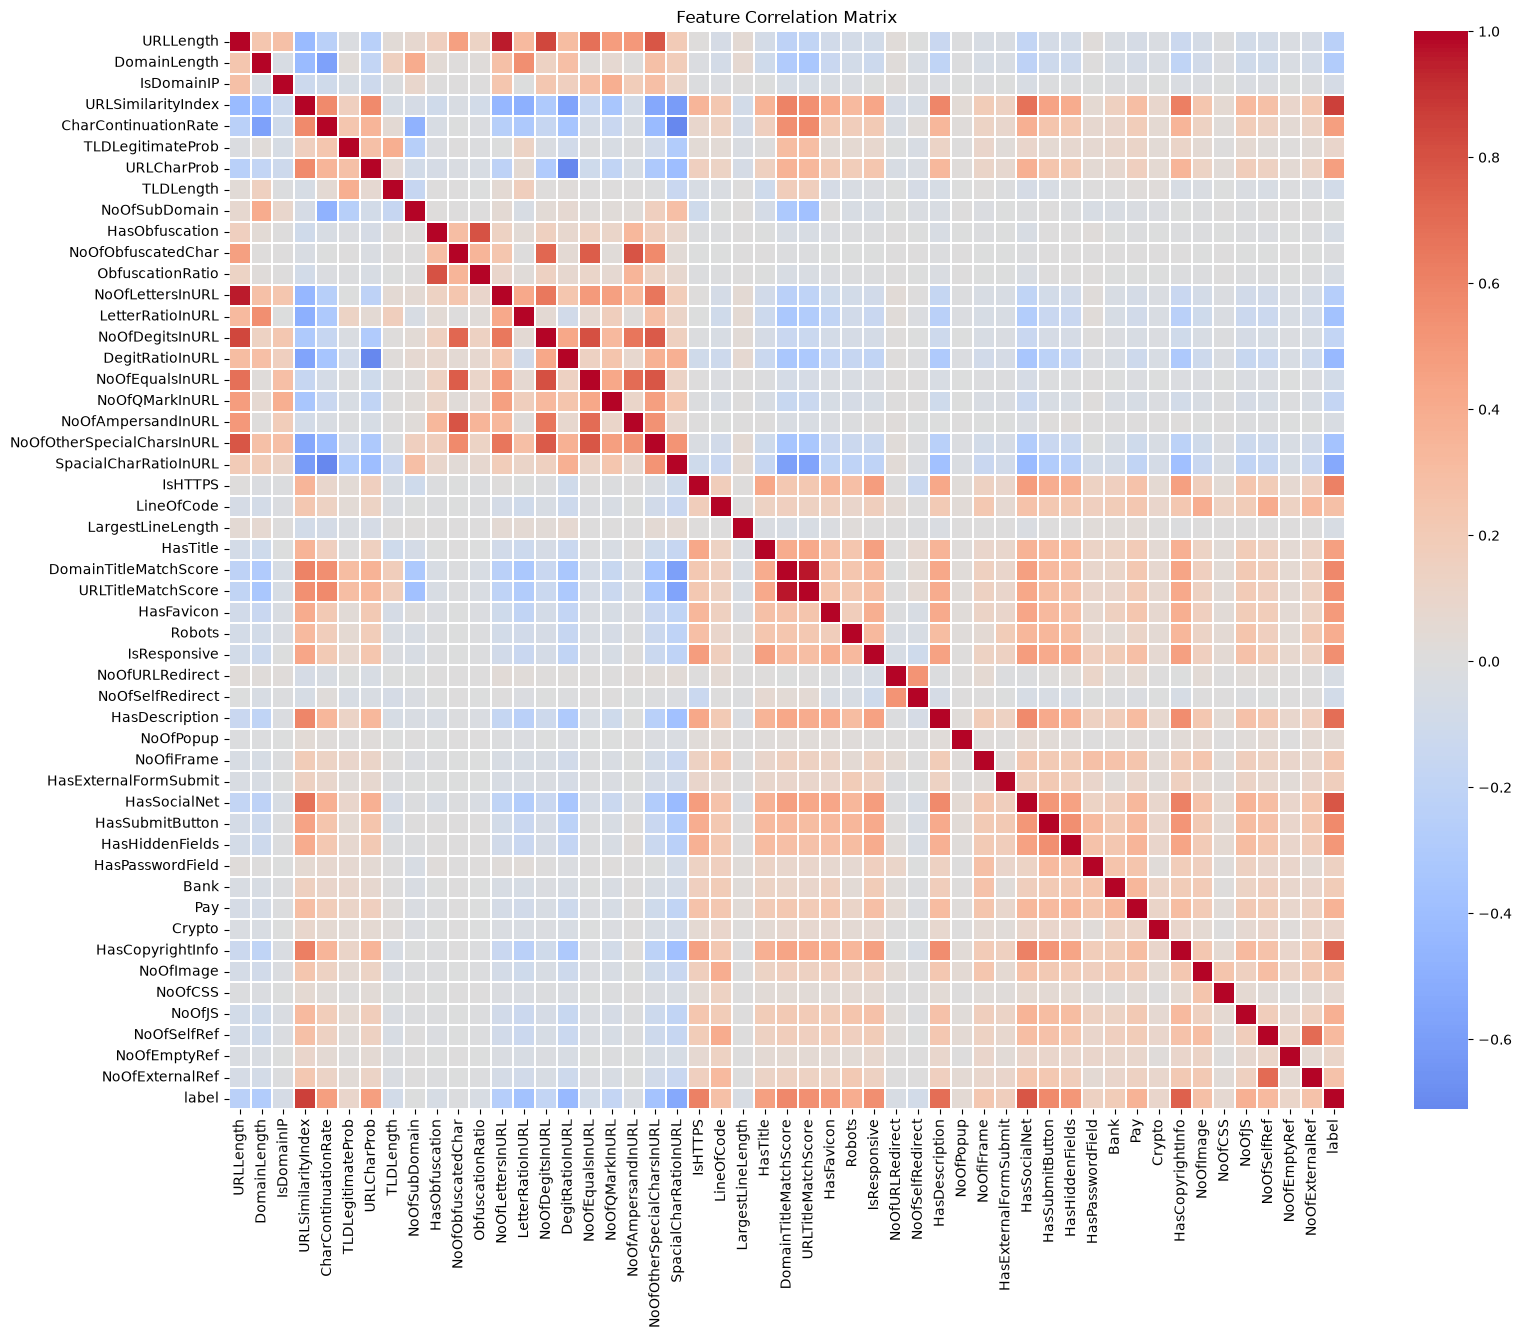

In [78]:
numeric_df = df.select_dtypes(
    include=["number"]
)

correlation = numeric_df.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.1
)

plt.title("Feature Correlation Matrix")

plt.show()

In [79]:
target_correlation = (
    numeric_df.corr()["label"]
    .sort_values(ascending=False)
)

target_correlation

label                         1.000000
URLSimilarityIndex            0.860358
HasSocialNet                  0.784255
HasCopyrightInfo              0.743358
HasDescription                0.690232
IsHTTPS                       0.609132
DomainTitleMatchScore         0.584905
HasSubmitButton               0.578561
IsResponsive                  0.548608
URLTitleMatchScore            0.539419
HasHiddenFields               0.507731
HasFavicon                    0.493711
URLCharProb                   0.469749
CharContinuationRate          0.467735
HasTitle                      0.459725
Robots                        0.392620
NoOfJS                        0.373500
Pay                           0.359747
NoOfSelfRef                   0.316211
NoOfImage                     0.274658
LineOfCode                    0.272257
NoOfExternalRef               0.258627
NoOfiFrame                    0.225822
Bank                          0.188959
HasExternalFormSubmit         0.167574
HasPasswordField         

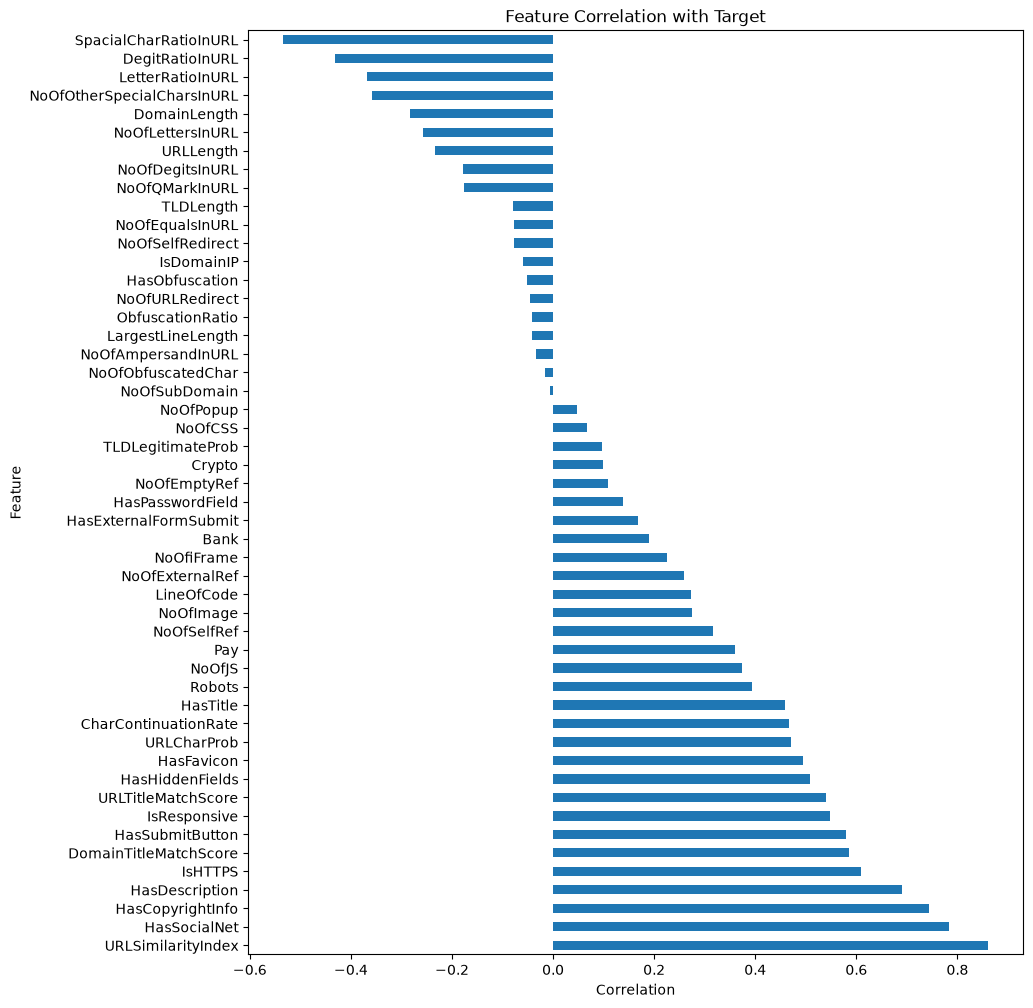

In [80]:
plt.figure(figsize=(10, 12))

target_correlation.drop("label").plot(
    kind="barh"
)

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.show()

In [81]:
target_column = "label"

feature_columns = [
    column
    for column in df.select_dtypes(include=["number"]).columns
    if column != target_column
]

print("Number of features:", len(feature_columns))

print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

Number of features: 50

Features:
- URLLength
- DomainLength
- IsDomainIP
- URLSimilarityIndex
- CharContinuationRate
- TLDLegitimateProb
- URLCharProb
- TLDLength
- NoOfSubDomain
- HasObfuscation
- NoOfObfuscatedChar
- ObfuscationRatio
- NoOfLettersInURL
- LetterRatioInURL
- NoOfDegitsInURL
- DegitRatioInURL
- NoOfEqualsInURL
- NoOfQMarkInURL
- NoOfAmpersandInURL
- NoOfOtherSpecialCharsInURL
- SpacialCharRatioInURL
- IsHTTPS
- LineOfCode
- LargestLineLength
- HasTitle
- DomainTitleMatchScore
- URLTitleMatchScore
- HasFavicon
- Robots
- IsResponsive
- NoOfURLRedirect
- NoOfSelfRedirect
- HasDescription
- NoOfPopup
- NoOfiFrame
- HasExternalFormSubmit
- HasSocialNet
- HasSubmitButton
- HasHiddenFields
- HasPasswordField
- Bank
- Pay
- Crypto
- HasCopyrightInfo
- NoOfImage
- NoOfCSS
- NoOfJS
- NoOfSelfRef
- NoOfEmptyRef
- NoOfExternalRef


In [82]:
X = df[feature_columns].copy()

y = df[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (235795, 50)
y shape: (235795,)


In [83]:
import numpy as np

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

print(
    "Total missing values:",
    X.isnull().sum().sum()
)

Total missing values: 0


In [84]:
X = X.fillna(
    X.median(numeric_only=True)
)

print(
    "Missing values after cleaning:",
    X.isnull().sum().sum()
)

Missing values after cleaning: 0


In [126]:
import pandas as pd
import numpy as np

URL_COLUMN = "URL"
LABEL_COLUMN = "label"

feature_rows = []
valid_indices = []

print("Extracting URL features from dataset...")

for index, url in enumerate(df[URL_COLUMN]):

    try:

        features = extract_url_features(str(url))

        feature_rows.append(features)
        valid_indices.append(index)

    except Exception as error:

        print(
            f"Skipping row {index}: {error}"
        )

print("\nFeature extraction completed.")

print(
    "Valid rows:",
    len(feature_rows)
)

Extracting URL features from dataset...

Feature extraction completed.
Valid rows: 235795


In [127]:
X = pd.DataFrame(feature_rows)

y = (
    df.loc[
        valid_indices,
        LABEL_COLUMN
    ]
    .reset_index(drop=True)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

X shape: (235795, 22)
y shape: (235795,)

Features:
['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDigitsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'NoOfLettersInDomain', 'NoOfDigitsInDomain', 'PathLength', 'IsHTTPS', 'HasPort', 'IsShortenedURL', 'SuspiciousWordCount', 'HasAtSymbol', 'HyphenCount', 'DotCount', 'QueryLength', 'FragmentLength']


In [128]:
print("Label distribution:")
print(y.value_counts())

print("\nUnique labels:")
print(y.unique())

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Unique labels:
[1 0]


In [129]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

print("Missing values:")
print(X.isnull().sum().sum())

print("Final shape:")
print(X.shape)

Missing values:
0
Final shape:
(235795, 22)


In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 188636
Testing samples: 47159

Training class distribution:
label
1    107880
0     80756
Name: count, dtype: int64

Testing class distribution:
label
1    26970
0    20189
Name: count, dtype: int64


In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (188636, 22)
Testing : (47159, 22)


In [138]:
y_pred = model.predict(X_test)

NameError: name 'model' is not defined

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [132]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [133]:
y_pred_lr = logistic_model.predict(
    X_test_scaled
)

y_prob_lr = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

print(y_pred_lr[:20])

[1 1 1 1 1 0 1 1 1 0 1 0 0 0 1 1 1 1 1 0]


In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

lr_auc = roc_auc_score(
    y_test,
    y_prob_lr
)

print("LOGISTIC REGRESSION")
print("===================")

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

LOGISTIC REGRESSION
Accuracy : 0.9999
Precision: 0.9998
Recall   : 1.0
F1 Score : 0.9999
ROC-AUC  : 1.0


In [135]:
y_pred = model.predict(X_test)

NameError: name 'model' is not defined

In [134]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    "F1:",
    f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

NameError: name 'y_pred' is not defined

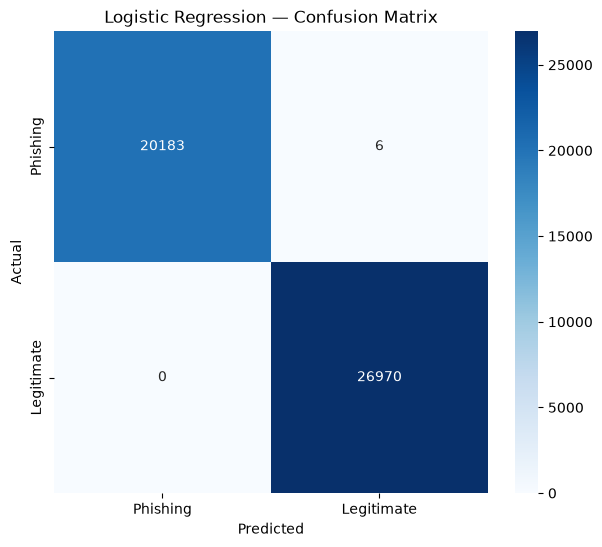

In [90]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Phishing", "Legitimate"],
    yticklabels=["Phishing", "Legitimate"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Logistic Regression — Confusion Matrix")

plt.show()

In [91]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [92]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [93]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

rf_auc = roc_auc_score(
    y_test,
    y_prob_rf
)

print("RANDOM FOREST")
print("=============")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

RANDOM FOREST
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


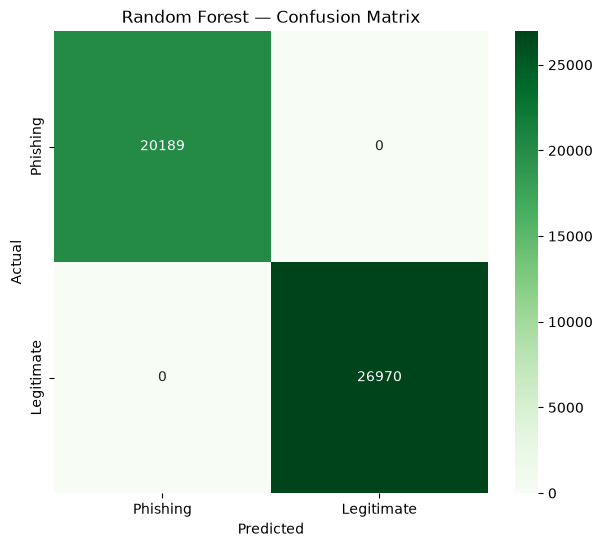

In [94]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Phishing", "Legitimate"],
    yticklabels=["Phishing", "Legitimate"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest — Confusion Matrix")

plt.show()

In [95]:
import pandas as pd
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(20)

,feature,importance
3,URLSimilarityIndex,0.205361
49,NoOfExternalRef,0.161393
22,LineOfCode,0.129199
44,NoOfImage,0.102141
47,NoOfSelfRef,0.083056
46,NoOfJS,0.069070
36,HasSocialNet,0.034515
45,NoOfCSS,0.031526
43,HasCopyrightInfo,0.026157
32,HasDescription,0.024415


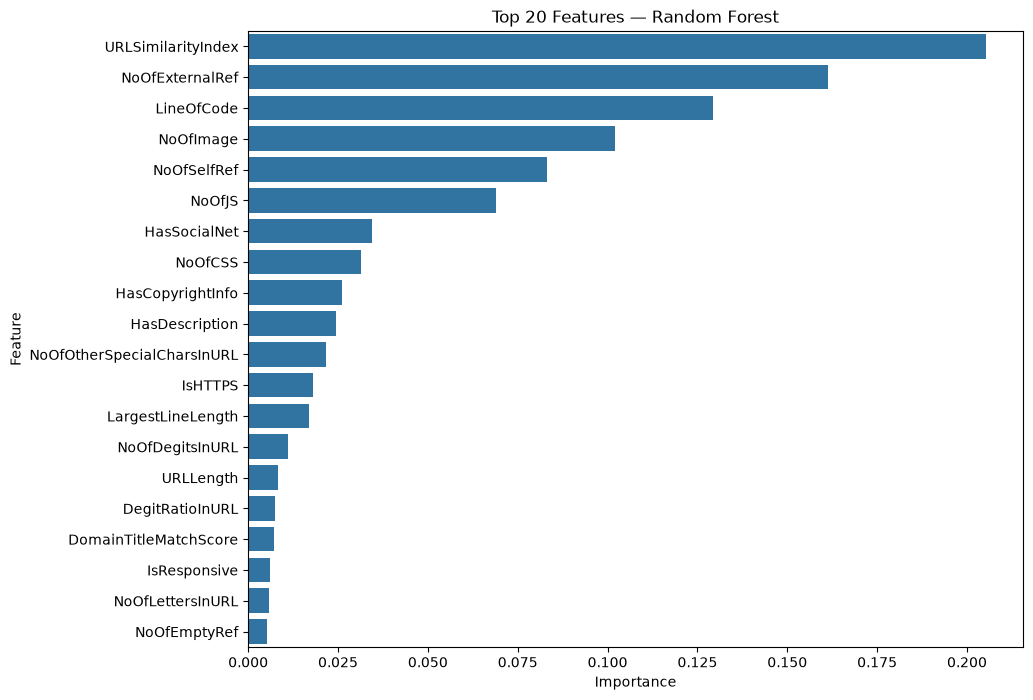

In [96]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title(
    "Top 20 Features — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

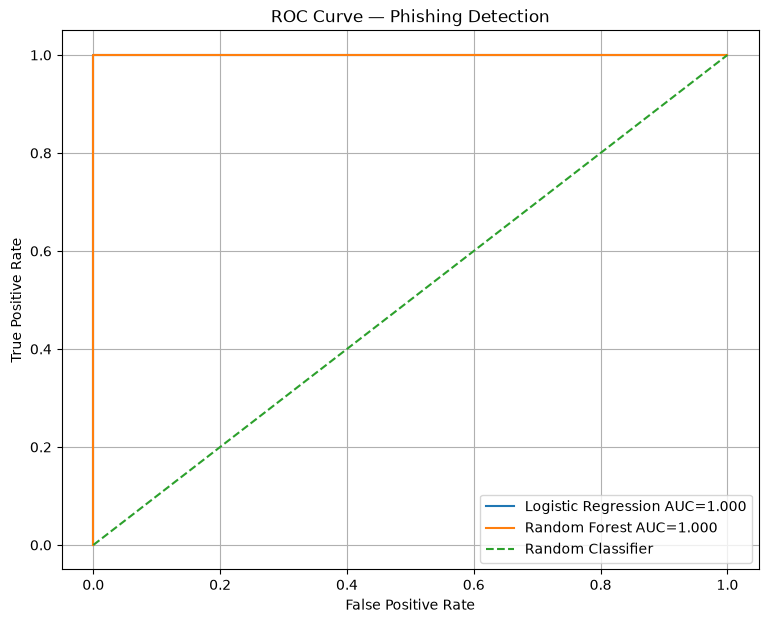

In [97]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC={lr_auc:.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC={rf_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve — Phishing Detection"
)

plt.legend()

plt.grid(True)

plt.show()

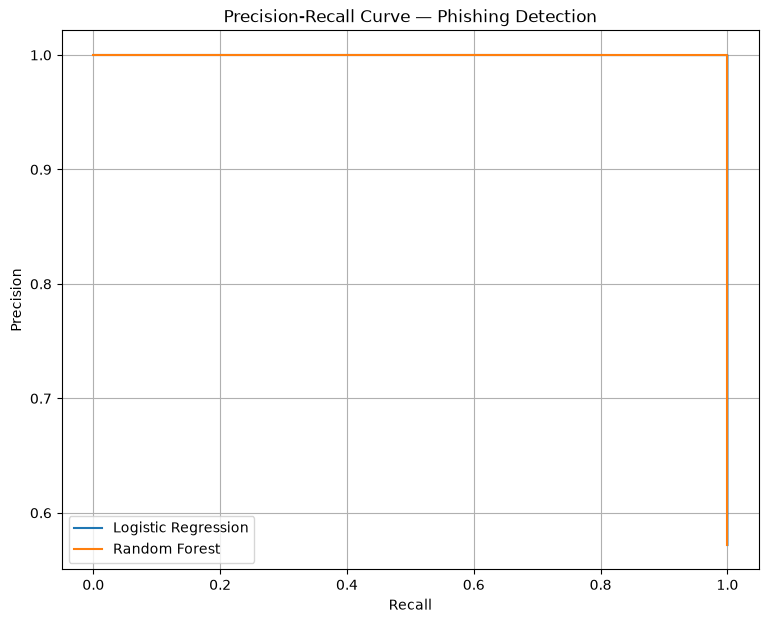

In [98]:
from sklearn.metrics import precision_recall_curve

precision_lr, recall_lr, _ = precision_recall_curve(
    y_test,
    y_prob_lr
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(9, 7))

plt.plot(
    recall_lr,
    precision_lr,
    label="Logistic Regression"
)

plt.plot(
    recall_rf,
    precision_rf,
    label="Random Forest"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve — Phishing Detection"
)

plt.legend()

plt.grid(True)

plt.show()

In [99]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.999873,0.999778,1.0,0.999889,1.0
1,Random Forest,1.000000,1.000000,1.0,1.000000,1.0


In [100]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9999,0.9998,1.0,0.9999,1.0
1,Random Forest,1.0000,1.0000,1.0,1.0000,1.0


In [101]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\MALAY\sentinel\ai\.venv\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [102]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

print("XGBoost trained successfully!")

XGBoost trained successfully!


In [103]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [104]:
xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb
)

xgb_precision = precision_score(
    y_test,
    y_pred_xgb
)

xgb_recall = recall_score(
    y_test,
    y_pred_xgb
)

xgb_f1 = f1_score(
    y_test,
    y_pred_xgb
)

xgb_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

print("XGBOOST")
print("=======")

print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))
print("ROC-AUC  :", round(xgb_auc, 4))

XGBOOST
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0


In [105]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9999,0.9998,1.0,0.9999,1.0
1,Random Forest,1.0000,1.0000,1.0,1.0000,1.0
2,XGBoost,1.0000,1.0000,1.0,1.0000,1.0


<Figure size 1200x600 with 0 Axes>

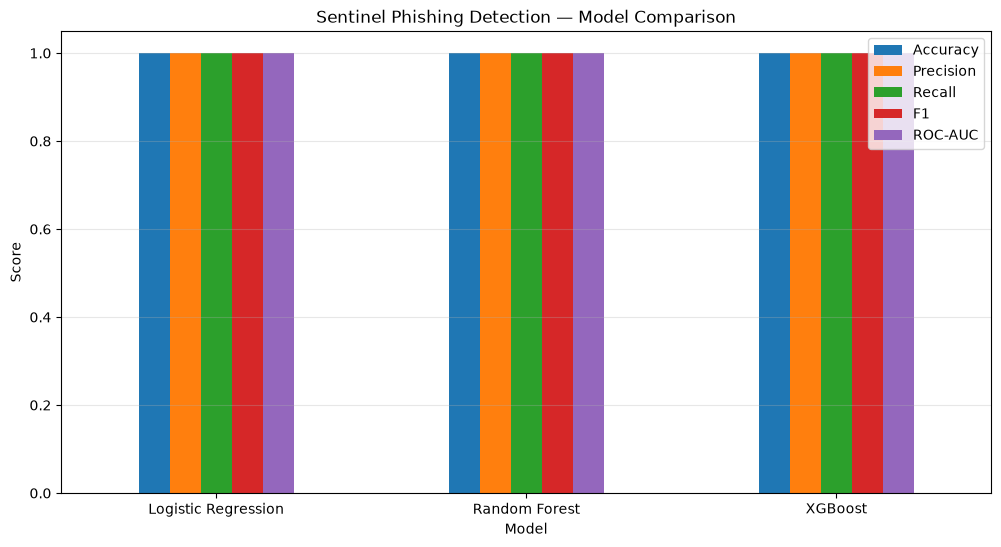

In [106]:
plt.figure(figsize=(12, 6))

results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Sentinel Phishing Detection — Model Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.show()

In [107]:
model_scores = {
    "Logistic Regression": lr_f1,
    "Random Forest": rf_f1,
    "XGBoost": xgb_f1
}

best_model_name = max(
    model_scores,
    key=model_scores.get
)

print("Best model:", best_model_name)
print("Best F1:", model_scores[best_model_name])

Best model: Random Forest
Best F1: 1.0


In [108]:
import joblib
import json

if best_model_name == "Logistic Regression":

    best_model = logistic_model
    model_scaler = scaler

elif best_model_name == "Random Forest":

    best_model = rf_model
    model_scaler = None

else:

    best_model = xgb_model
    model_scaler = None


MODEL_PATH = PHISHING_MODEL_DIR / "phishing_model.pkl"

SCALER_PATH = PHISHING_MODEL_DIR / "scaler.pkl"

FEATURES_PATH = PHISHING_MODEL_DIR / "features.json"

METRICS_PATH = PHISHING_MODEL_DIR / "metrics.json"


joblib.dump(
    best_model,
    MODEL_PATH
)

if model_scaler is not None:
    joblib.dump(
        model_scaler,
        SCALER_PATH
)

with open(
    FEATURES_PATH,
    "w"
) as f:

    json.dump(
        feature_columns,
        f,
        indent=4
    )


metrics = {
    "model": best_model_name,
    "accuracy": float(
        results.loc[
            results["Model"] == best_model_name,
            "Accuracy"
        ].iloc[0]
    ),
    "precision": float(
        results.loc[
            results["Model"] == best_model_name,
            "Precision"
        ].iloc[0]
    ),
    "recall": float(
        results.loc[
            results["Model"] == best_model_name,
            "Recall"
        ].iloc[0]
    ),
    "f1": float(
        results.loc[
            results["Model"] == best_model_name,
            "F1"
        ].iloc[0]
    ),
    "roc_auc": float(
        results.loc[
            results["Model"] == best_model_name,
            "ROC-AUC"
        ].iloc[0]
    )
}

with open(
    METRICS_PATH,
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )


print("Model saved:")
print(MODEL_PATH)

print("\nFeatures saved:")
print(FEATURES_PATH)

print("\nMetrics saved:")
print(METRICS_PATH)

Model saved:
C:\Users\MALAY\sentinel\ai\models\phishing\phishing_model.pkl

Features saved:
C:\Users\MALAY\sentinel\ai\models\phishing\features.json

Metrics saved:
C:\Users\MALAY\sentinel\ai\models\phishing\metrics.json


In [109]:
loaded_model = joblib.load(
    MODEL_PATH
)

print(
    "Loaded model:",
    type(loaded_model)
)

Loaded model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [110]:
sample = X_test.iloc[[0]]

actual = y_test.iloc[0]

prediction = loaded_model.predict(
    sample
)[0]

print("Actual:", actual)
print("Predicted:", prediction)

Actual: 1
Predicted: 1


In [111]:
probability = loaded_model.predict_proba(
    sample
)[0]

print("Probability:", probability)

Probability: [0. 1.]


In [112]:
phishing_probability = probability[0]

risk_score = phishing_probability * 100

print(
    f"Phishing Risk: {risk_score:.2f}%"
)

Phishing Risk: 0.00%


In [113]:
if risk_score >= 80:

    risk_level = "CRITICAL"

elif risk_score >= 60:

    risk_level = "HIGH"

elif risk_score >= 30:

    risk_level = "MEDIUM"

else:

    risk_level = "LOW"


print("Risk Level:", risk_level)

Risk Level: LOW


In [114]:
from datasets import load_phishing_dataset

ModuleNotFoundError: No module named 'datasets'

In [ ]:
from pathlib import Path
import sys

AI_ROOT = Path(r"C:\Users\MALAY\sentinel\ai")
APP_ROOT = AI_ROOT / "app"
DATASET_PATH = AI_ROOT / "datasets" / "phiusiil.csv"

MODEL_ROOT = AI_ROOT / "models"
PHISHING_MODEL_DIR = MODEL_ROOT / "phishing"

PHISHING_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

sys.path.insert(
    0,
    str(APP_ROOT)
)

print(DATASET_PATH)
print("Exists:", DATASET_PATH.exists())

C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv
Exists: True


In [ ]:
from src.data_loader import load_phishing_dataset

df = load_phishing_dataset()

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

df.head()

Loading dataset from:
C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv
Dataset loaded successfully.
Shape: (235795, 56)
Dataset shape: (235795, 56)
Columns: ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoO

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1


In [ ]:
print(df.columns.tolist())

['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [ ]:
with open(
    r"C:\Users\MALAY\sentinel\ai\models\phishing\features.json",
    "r"
) as f:
    model_features = json.load(f)

print(model_features)

['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


In [ ]:
from services.url_feature_extractor import extract_url_features

test_url = "https://example.com/login"

test_features = extract_url_features(test_url)

print(test_features)

{'URLLength': 25, 'DomainLength': 11, 'IsDomainIP': 0, 'NoOfSubDomain': 0, 'NoOfLettersInURL': 20, 'NoOfDigitsInURL': 0, 'NoOfEqualsInURL': 0, 'NoOfQMarkInURL': 0, 'NoOfAmpersandInURL': 0, 'NoOfOtherSpecialCharsInURL': 1, 'NoOfLettersInDomain': 10, 'NoOfDigitsInDomain': 0, 'PathLength': 6, 'IsHTTPS': 1, 'HasPort': 0, 'IsShortenedURL': 0, 'SuspiciousWordCount': 1, 'HasAtSymbol': 0, 'HyphenCount': 0, 'DotCount': 1, 'QueryLength': 0, 'FragmentLength': 0}


In [ ]:
def calculate_risk(phishing_probability):

    risk_score = phishing_probability * 100

    if risk_score >= 80:
        level = "CRITICAL"

    elif risk_score >= 60:
        level = "HIGH"

    elif risk_score >= 30:
        level = "MEDIUM"

    else:
        level = "LOW"

    return {
        "score": round(risk_score, 2),
        "level": level
    }

In [ ]:
def generate_reasons(features):

    reasons = []

    if features.get("IsDomainIP") == 1:
        reasons.append({
            "severity": "HIGH",
            "reason": "Domain uses an IP address instead of a normal domain"
        })

    if features.get("URLLength", 0) > 100:
        reasons.append({
            "severity": "HIGH",
            "reason": "URL is unusually long"
        })

    if features.get("NoOfSubDomain", 0) >= 3:
        reasons.append({
            "severity": "HIGH",
            "reason": "Multiple subdomains detected"
        })

    if features.get("NoOfDigitsInURL", 0) >= 10:
        reasons.append({
            "severity": "MEDIUM",
            "reason": "High number of digits in URL"
        })

    if features.get("HasAtSymbol") == 1:
        reasons.append({
            "severity": "HIGH",
            "reason": "@ symbol detected in URL"
        })

    if features.get("IsShortenedURL") == 1:
        reasons.append({
            "severity": "MEDIUM",
            "reason": "URL shortening service detected"
        })

    if features.get("SuspiciousWordCount", 0) > 0:
        reasons.append({
            "severity": "MEDIUM",
            "reason": "Security-sensitive words detected in URL"
        })

    if not reasons:
        reasons.append({
            "severity": "INFO",
            "reason": "No obvious URL-level indicators detected"
        })

    return reasons

In [116]:


df = load_phishing_dataset()

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

Loading dataset from:
C:\Users\MALAY\sentinel\ai\datasets\phiusiil.csv
Dataset loaded successfully.
Shape: (235795, 56)
Dataset shape: (235795, 56)
Columns: ['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoO

In [117]:
import sys
import os

sys.path.insert(
    0,
    r"C:\Users\MALAY\sentinel\ai\app"
)

from services.url_feature_extractor import extract_url_features

print("URL feature extractor imported successfully")

URL feature extractor imported successfully


In [118]:
print("Dataset columns:")
for i, column in enumerate(df.columns):
    print(i, column)

Dataset columns:
0 FILENAME
1 URL
2 URLLength
3 Domain
4 DomainLength
5 IsDomainIP
6 TLD
7 URLSimilarityIndex
8 CharContinuationRate
9 TLDLegitimateProb
10 URLCharProb
11 TLDLength
12 NoOfSubDomain
13 HasObfuscation
14 NoOfObfuscatedChar
15 ObfuscationRatio
16 NoOfLettersInURL
17 LetterRatioInURL
18 NoOfDegitsInURL
19 DegitRatioInURL
20 NoOfEqualsInURL
21 NoOfQMarkInURL
22 NoOfAmpersandInURL
23 NoOfOtherSpecialCharsInURL
24 SpacialCharRatioInURL
25 IsHTTPS
26 LineOfCode
27 LargestLineLength
28 HasTitle
29 Title
30 DomainTitleMatchScore
31 URLTitleMatchScore
32 HasFavicon
33 Robots
34 IsResponsive
35 NoOfURLRedirect
36 NoOfSelfRedirect
37 HasDescription
38 NoOfPopup
39 NoOfiFrame
40 HasExternalFormSubmit
41 HasSocialNet
42 HasSubmitButton
43 HasHiddenFields
44 HasPasswordField
45 Bank
46 Pay
47 Crypto
48 HasCopyrightInfo
49 NoOfImage
50 NoOfCSS
51 NoOfJS
52 NoOfSelfRef
53 NoOfEmptyRef
54 NoOfExternalRef
55 label


In [139]:
test_url = "https://www.google.com"

test_features = extract_url_features(test_url)

print("Number of extracted features:")
print(len(test_features))

print("\nFeatures:")
for key, value in test_features.items():
    print(f"{key:35} : {value}")

Number of extracted features:
22

Features:
URLLength                           : 22
DomainLength                        : 14
IsDomainIP                          : 0
NoOfSubDomain                       : 1
NoOfLettersInURL                    : 17
NoOfDigitsInURL                     : 0
NoOfEqualsInURL                     : 0
NoOfQMarkInURL                      : 0
NoOfAmpersandInURL                  : 0
NoOfOtherSpecialCharsInURL          : 1
NoOfLettersInDomain                 : 12
NoOfDigitsInDomain                  : 0
PathLength                          : 0
IsHTTPS                             : 1
HasPort                             : 0
IsShortenedURL                      : 0
SuspiciousWordCount                 : 0
HasAtSymbol                         : 0
HyphenCount                         : 0
DotCount                            : 2
QueryLength                         : 0
FragmentLength                      : 0


In [120]:
import pandas as pd
import numpy as np

URL_COLUMN = "URL"
LABEL_COLUMN = "label"

feature_rows = []
valid_indices = []

print("Extracting URL features from dataset...")

for index, url in enumerate(df[URL_COLUMN]):

    try:

        features = extract_url_features(str(url))

        feature_rows.append(features)
        valid_indices.append(index)

    except Exception as error:

        print(
            f"Skipping row {index}: {error}"
        )

print("\nFeature extraction completed.")

print(
    "Valid rows:",
    len(feature_rows)
)

Extracting URL features from dataset...

Feature extraction completed.
Valid rows: 235795


In [121]:
X = pd.DataFrame(feature_rows)

y = (
    df.loc[
        valid_indices,
        LABEL_COLUMN
    ]
    .reset_index(drop=True)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

X shape: (235795, 22)
y shape: (235795,)

Features:
['URLLength', 'DomainLength', 'IsDomainIP', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDigitsInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'NoOfLettersInDomain', 'NoOfDigitsInDomain', 'PathLength', 'IsHTTPS', 'HasPort', 'IsShortenedURL', 'SuspiciousWordCount', 'HasAtSymbol', 'HyphenCount', 'DotCount', 'QueryLength', 'FragmentLength']


In [122]:
print("Label distribution:")
print(y.value_counts())

print("\nUnique labels:")
print(y.unique())

Label distribution:
label
1    134850
0    100945
Name: count, dtype: int64

Unique labels:
[1 0]
